# Model Performance Metrics Visualization
Load a JSON metrics file and produce:
1. Per-class bar plots (precision, recall, F1, IoU)
2. A colored confusion matrix

Works for both binary and multiclass models.

In [3]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# Get script directory
SCRIPT_DIR = Path.cwd()
if SCRIPT_DIR.name != "DL_Pipeline_v2":
    SCRIPT_DIR = Path.cwd() / "Python_Code_Analysis" / "DL_Pipeline_v2"

# Add script dir to path for module imports
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

# Project root
PROJECT_ROOT = SCRIPT_DIR.parent.parent

In [4]:
# ---- CONFIGURATION ----
# Point this to your metrics JSON
METRICS_PATH = f"{PROJECT_ROOT}/Models/best_multiclass_unet3plus_bf64_d4_20260605_1537_evaluation_metrics.json"
META_PATH = f"{PROJECT_ROOT}/Models/best_multiclass_unet3plus_bf64_d4_20260605_1537.meta.json"

with open(METRICS_PATH) as f:
    metrics = json.load(f)
with open(META_PATH) as f:
    meta = json.load(f)

class_names = list(metrics["per_class"].keys())
n_classes = len(class_names)
print(f"Model type: {'binary' if n_classes == 2 else 'multiclass'} ({n_classes} classes)")
print(f"Classes: {class_names}")

Model type: multiclass (4 classes)
Classes: ['EMW', 'FSW', 'SSW', 'UPL']


## Per-Class Metrics Bar Plot

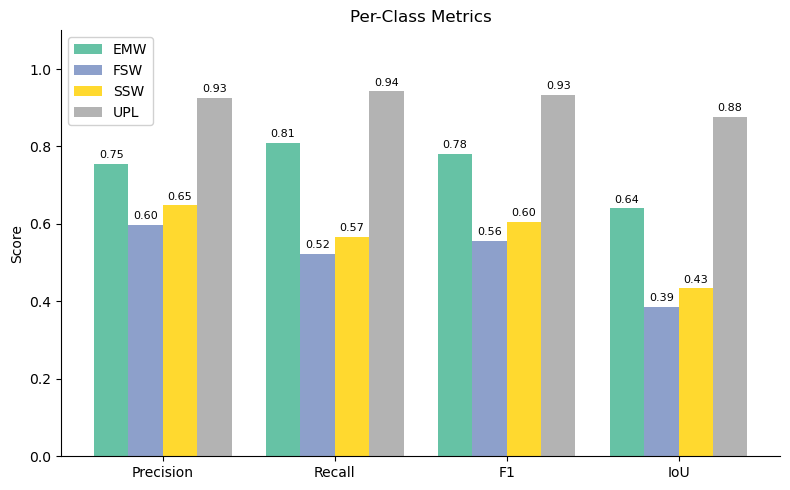

In [5]:
metric_names = ["precision", "recall", "f1", "iou"]
metric_labels = ["Precision", "Recall", "F1", "IoU"]

# Build array: rows = classes, cols = metrics
values = np.array([
    [metrics["per_class"][c][m] for m in metric_names]
    for c in class_names
])

x = np.arange(len(metric_names))
width = 0.8 / n_classes
colors = plt.cm.Set2(np.linspace(0, 1, max(n_classes, 3)))

fig, ax = plt.subplots(figsize=(8, 5))
for i, cname in enumerate(class_names):
    offset = (i - (n_classes - 1) / 2) * width
    bars = ax.bar(x + offset, values[i], width, label=cname, color=colors[i])
    for bar, val in zip(bars, values[i]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Per-Class Metrics")
ax.legend(loc="upper left", framealpha=0.9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/Models/{meta['arch']}_{meta['classification_mode']}_per_class_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

## Confusion Matrix

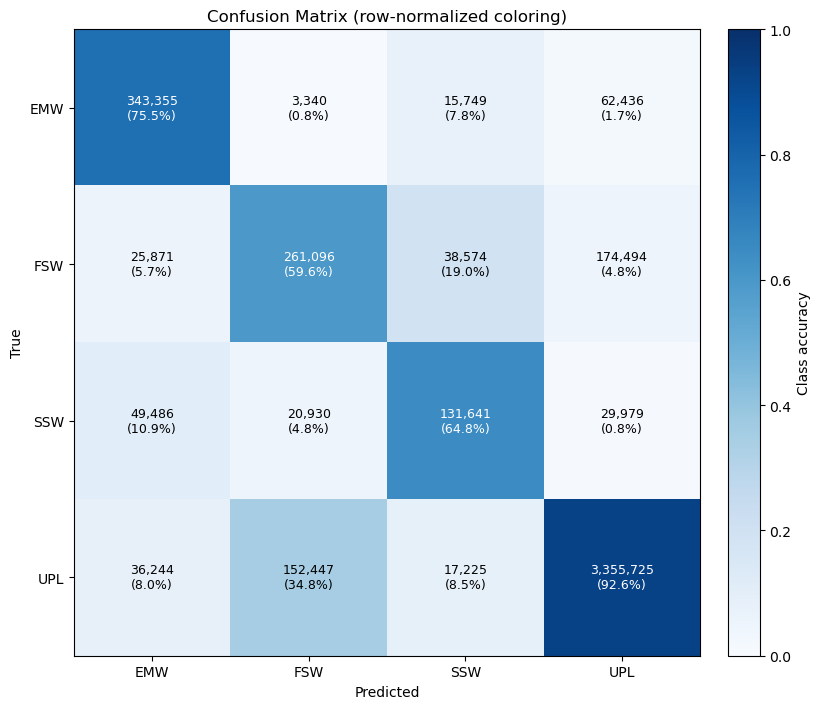

In [42]:
cm = np.array(metrics["confusion_matrix"])

# Row-normalized for coloring (each row sums to 1)
cm_norm = cm.astype(float) / cm.sum(axis=0, keepdims=True)

fig, ax = plt.subplots(figsize=(5 + n_classes * 0.8, 4 + n_classes * 0.8))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

# Annotate cells with raw count + percentage
for i in range(n_classes):
    for j in range(n_classes):
        pct = cm_norm[i, j]
        color = "white" if pct > 0.55 else "black"
        ax.text(j, i, f"{cm[i, j]:,}\n({pct:.1%})",
                ha="center", va="center", fontsize=9, color=color)

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (row-normalized coloring)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Class accuracy")
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/Models/{meta['arch']}_{meta['classification_mode']}_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary Table

In [43]:
print(f"Overall Accuracy:  {metrics['overall_accuracy']:.4f}")
print(f"Macro Precision:   {metrics['macro_precision']:.4f}")
print(f"Macro Recall:      {metrics['macro_recall']:.4f}")
print(f"Macro F1:          {metrics['macro_f1']:.4f}")
print(f"Mean IoU:          {metrics['mean_iou']:.4f}")

Overall Accuracy:  0.8672
Macro Precision:   0.7313
Macro Recall:      0.7099
Macro F1:          0.7191
Mean IoU:          0.5840


## Export Settings + Metrics Table (CSV)
Flatten the `.meta.json` settings and the evaluation metrics into a two-column
`Metric/Setting | Value` table, save it as a CSV, and display it for copy/paste
into a document or spreadsheet.

In [ ]:
import pandas as pd

def _fmt(v):
    """Render values cleanly: lists as comma-joined, floats trimmed, bools lowercased."""
    if isinstance(v, bool):
        return str(v).lower()
    if isinstance(v, (list, tuple)):
        return ", ".join(str(x) for x in v)
    if isinstance(v, float):
        return f"{v:.4f}".rstrip("0").rstrip(".")
    return v

rows = []

# ---- Model settings (from .meta.json) ----
setting_keys = [
    "in_channels", "num_classes", "base_filters", "depth", "dropout",
    "use_aspp", "aspp_rates", "classification_mode", "epoch",
    "class_names", "ignore_index", "source_checkpoint", "export_timestamp",
]
for k in setting_keys:
    if k in meta:
        rows.append((k, _fmt(meta[k])))

# ---- Overall metrics ----
for k in ["overall_accuracy", "macro_precision", "macro_recall", "macro_f1", "mean_iou"]:
    if k in metrics:
        rows.append((k, _fmt(metrics[k])))

# ---- Per-class metrics ----
for cname, m in metrics["per_class"].items():
    for metric_key in ["precision", "recall", "f1", "iou", "support"]:
        if metric_key in m:
            rows.append((f"{cname}_{metric_key}", _fmt(m[metric_key])))

table = pd.DataFrame(rows, columns=["Metric/Setting", "Value"])

# Save CSV next to the metrics file, using the model name as the stem
stem = Path(METRICS_PATH).name.replace("_evaluation_metrics.json", "")
csv_path = f"{PROJECT_ROOT}/Models/{stem}_summary_table.csv"
table.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

table